Install required libraries

In [ ]:
!pip install ultralytics -q
print("Done")

✅ Done


Convert BDD100K JSON labels → YOLO format

In [17]:
import json, os
from pathlib import Path

# BDD100K class name → our unified class id
BDD_CLASS_MAP = {
    'car':        0,
    'truck':      1,
    'bus':        2,
    'motorcycle': 3,
    'motor':      3,
    'person':     4,
    'rider':      4,
    # ignore: traffic light, traffic sign, train, bike
}

def convert_bdd_json_to_yolo(json_path, img_dir, out_label_dir, img_w=1280, img_h=720):
    """
    Reads BDD100K JSON annotation file, converts each image's
    bounding boxes to YOLO format .txt files.
    """
    Path(out_label_dir).mkdir(parents=True, exist_ok=True)

    with open(json_path) as f:
        data = json.load(f)

    converted, skipped = 0, 0
    for item in data:
        img_name = item['name']
        img_path = Path(img_dir) / img_name

        if not img_path.exists():
            skipped += 1
            continue

        labels = item.get('labels', [])
        lines = []
        for lbl in labels:
            cat = lbl.get('category', '')
            if cat not in BDD_CLASS_MAP:
                continue
            cls_id = BDD_CLASS_MAP[cat]

            box = lbl.get('box2d')
            if not box:
                continue

            # Convert to YOLO normalized xywh
            x1, y1, x2, y2 = box['x1'], box['y1'], box['x2'], box['y2']
            cx = ((x1 + x2) / 2) / img_w
            cy = ((y1 + y2) / 2) / img_h
            w  = (x2 - x1) / img_w
            h  = (y2 - y1) / img_h

            # Skip invalid boxes
            if w <= 0 or h <= 0:
                continue

            lines.append(f"{cls_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")

        if not lines:
            skipped += 1
            continue

        stem = Path(img_name).stem
        with open(Path(out_label_dir) / f"{stem}.txt", 'w') as f:
            f.write('\n'.join(lines))
        converted += 1

    print(f"  ✅ Converted: {converted}  |  Skipped: {skipped}")

# --- Run conversion ---
BDD_BASE   = '/kaggle/input/datasets/solesensei/solesensei_bdd100k'
BDD_IMGS   = f'{BDD_BASE}/bdd100k/bdd100k/images/100k'
BDD_LABELS = f'{BDD_BASE}/bdd100k_labels_release/bdd100k/labels'
BDD_OUT    = '/kaggle/working/bdd_yolo_labels'

print("Converting BDD100K train labels...")
convert_bdd_json_to_yolo(
    json_path = f'{BDD_LABELS}/bdd100k_labels_images_train.json',
    img_dir   = f'{BDD_IMGS}/train',
    out_label_dir = f'{BDD_OUT}/train'
)

print("Converting BDD100K val labels...")
convert_bdd_json_to_yolo(
    json_path = f'{BDD_LABELS}/bdd100k_labels_images_val.json',
    img_dir   = f'{BDD_IMGS}/val',
    out_label_dir = f'{BDD_OUT}/val'
)

Converting BDD100K train labels...
  ✅ Converted: 1141  |  Skipped: 68722
Converting BDD100K val labels...
  ✅ Converted: 9921  |  Skipped: 79


Combine BDD100K + VisDrone into one folder

In [18]:
import shutil
from pathlib import Path

# VisDrone class id → our unified class id
# 0=pedestrian, 1=person, 2=bicycle, 3=car, 4=van, 5=truck, 6=tricycle, 7=aw-tricycle, 8=bus, 9=motor
VISDRONE_MAP = {3: 0, 4: 0, 5: 1, 8: 2, 9: 3, 0: 4, 1: 4}

def copy_bdd(src_img_dir, src_label_dir, split, limit=None, prefix='bdd'):
    out_img = Path(f'/kaggle/working/combined/{split}/images')
    out_lbl = Path(f'/kaggle/working/combined/{split}/labels')
    out_img.mkdir(parents=True, exist_ok=True)
    out_lbl.mkdir(parents=True, exist_ok=True)

    imgs = sorted(Path(src_img_dir).glob('*.jpg'))
    if limit:
        imgs = imgs[:limit]

    copied = 0
    for img in imgs:
        lbl = Path(src_label_dir) / (img.stem + '.txt')
        if not lbl.exists():
            continue
        shutil.copy(img, out_img / f"{prefix}_{img.name}")
        shutil.copy(lbl, out_lbl / f"{prefix}_{img.stem}.txt")
        copied += 1
    print(f"   BDD {split}: {copied} images copied")


def copy_visdrone(src_img_dir, src_label_dir, split, limit=None, prefix='vis'):
    out_img = Path(f'/kaggle/working/combined/{split}/images')
    out_lbl = Path(f'/kaggle/working/combined/{split}/labels')
    out_img.mkdir(parents=True, exist_ok=True)
    out_lbl.mkdir(parents=True, exist_ok=True)

    imgs = sorted(
        list(Path(src_img_dir).glob('*.jpg')) +
        list(Path(src_img_dir).glob('*.png'))
    )
    if limit:
        imgs = imgs[:limit]

    copied, skipped = 0, 0
    for img in imgs:
        lbl = Path(src_label_dir) / (img.stem + '.txt')
        if not lbl.exists():
            skipped += 1
            continue

        # Remap VisDrone class ids
        new_lines = []
        with open(lbl) as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cls = int(parts[0])
                if cls in VISDRONE_MAP:
                    new_lines.append(f"{VISDRONE_MAP[cls]} {' '.join(parts[1:])}")

        if not new_lines:
            skipped += 1
            continue

        shutil.copy(img, out_img / f"{prefix}_{img.name}")
        with open(out_lbl / f"{prefix}_{img.stem}.txt", 'w') as f:
            f.write('\n'.join(new_lines))
        copied += 1

    print(f"   VisDrone {split}: {copied} copied, {skipped} skipped")


VIS_BASE = '/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset'

print(" Copying BDD100K...")
copy_bdd(
    src_img_dir   = f'{BDD_IMGS}/train',
    src_label_dir = f'{BDD_OUT}/train',
    split='train', limit=1000  # all 1160 train images
)
copy_bdd(
    src_img_dir   = f'{BDD_IMGS}/val',
    src_label_dir = f'{BDD_OUT}/val',
    split='val', limit=200
)

print("\n Copying VisDrone...")
copy_visdrone(
    src_img_dir   = f'{VIS_BASE}/VisDrone2019-DET-train/images',
    src_label_dir = f'{VIS_BASE}/VisDrone2019-DET-train/labels',
    split='train', limit=5000
)
copy_visdrone(
    src_img_dir   = f'{VIS_BASE}/VisDrone2019-DET-val/images',
    src_label_dir = f'{VIS_BASE}/VisDrone2019-DET-val/labels',
    split='val', limit=800
)

# Final count
for split in ['train', 'val']:
    n = len(list(Path(f'/kaggle/working/combined/{split}/images').glob('*')))
    print(f"\n {split}: {n} total images")

 Copying BDD100K...
   BDD train: 987 images copied
   BDD val: 199 images copied

 Copying VisDrone...
   VisDrone train: 5000 copied, 0 skipped
   VisDrone val: 548 copied, 0 skipped

 train: 5987 total images

 val: 747 total images


Write data.yaml

In [19]:
import yaml

data = {
    'path': '/kaggle/working/combined',
    'train': 'train/images',
    'val':   'val/images',
    'nc': 5,
    'names': ['car', 'truck', 'bus', 'motorcycle', 'person']
}

with open('/kaggle/working/combined/data.yaml', 'w') as f:
    yaml.dump(data, f, default_flow_style=False)

print(" data.yaml saved:")
print(yaml.dump(data))

 data.yaml saved:
names:
- car
- truck
- bus
- motorcycle
- person
nc: 5
path: /kaggle/working/combined
train: train/images
val: val/images



Train yoloV8 model

In [21]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')

results = model.train(
    data    = '/kaggle/working/combined/data.yaml',
    epochs  = 60,
    imgsz   = 640,
    batch   = 16,
    name    = 'traffic_v2',
    patience= 20,
    save    = True,
    plots   = True,
    augment = True,
    mosaic  = 1.0,
    mixup   = 0.15,
    hsv_h   = 0.015,
    hsv_s   = 0.7,
    hsv_v   = 0.4,
    fliplr  = 0.5,
    scale   = 0.5,
    degrees = 5.0,
    cos_lr  = True,
    lr0     = 0.001,
    warmup_epochs = 3,
    device  = 0,
    project = '/kaggle/working/runs',
    exist_ok= True,
)
print("✅ Training done!")

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/combined/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=traffic_v2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspe

Generate density CSV

In [22]:
import os, pandas as pd, numpy as np
from pathlib import Path
from ultralytics import YOLO

# Point to your saved Run 1 weights
model_trained = YOLO('/kaggle/working/runs/traffic_v2/weights/best.pt')

test_dir = '/kaggle/working/combined/val/images'
images   = sorted(Path(test_dir).glob('*'))
print(f"Running on {len(images)} images...")

VEHICLE_CLASSES = {0, 1, 2, 3}
records = []

for i, img_path in enumerate(images):
    if i % 100 == 0:
        print(f"  {i}/{len(images)}")
    r = model_trained(str(img_path), conf=0.35, verbose=False)[0]
    count = sum(1 for box in r.boxes if int(box.cls) in VEHICLE_CLASSES)
    level = 0 if count <= 5 else (1 if count <= 15 else (2 if count <= 30 else 3))
    records.append({'frame': i, 'count': count, 'level': level})

df = pd.DataFrame(records)
df.to_csv('/kaggle/working/density_data.csv', index=False)
print(f"\n✅ Saved {len(df)} rows")
print(df['level'].value_counts().rename({0:'Low',1:'Medium',2:'High',3:'Critical'}))

Running on 747 images...
  0/747
  100/747
  200/747
  300/747
  400/747
  500/747
  600/747
  700/747

✅ Saved 747 rows
level
Critical    241
Medium      188
High        180
Low         138
Name: count, dtype: int64


Train LSTM model

In [23]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np

class CongestionLSTM(nn.Module):
    def __init__(self, input_size=2, hidden_size=128, num_layers=2, output_size=4):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=0.3)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, output_size)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class DensityDataset(Dataset):
    def __init__(self, data, window=20):  # window=20 since we only have 747 rows
        self.window = window
        self.data   = data.copy().astype(np.float32)
        self.data[:, 0] /= 50.0
        self.data[:, 1] /= 3.0
    def __len__(self):
        return max(0, len(self.data) - self.window - 1)
    def __getitem__(self, idx):
        x = self.data[idx : idx + self.window]
        y = int(round(self.data[idx + self.window, 1] * 3))
        y = max(0, min(3, y))
        return torch.tensor(x), torch.tensor(y, dtype=torch.long)

df   = pd.read_csv('/kaggle/working/density_data.csv')
data = df[['count', 'level']].values
split = int(len(data) * 0.8)

train_ds     = DensityDataset(data[:split], window=20)
val_ds       = DensityDataset(data[split:], window=20)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32)

print(f"Train samples: {len(train_ds)}, Val samples: {len(val_ds)}")

device     = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using: {device}")

model_lstm = CongestionLSTM().to(device)
optimizer  = torch.optim.Adam(model_lstm.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
criterion  = nn.CrossEntropyLoss()

best_val = float('inf')
for epoch in range(1, 101):
    model_lstm.train()
    tl = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model_lstm(x), y)
        loss.backward()
        nn.utils.clip_grad_norm_(model_lstm.parameters(), 1.0)
        optimizer.step()
        tl += loss.item()
    tl /= len(train_loader)

    model_lstm.eval()
    vl, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out  = model_lstm(x)
            vl  += criterion(out, y).item()
            correct += (out.argmax(1) == y).sum().item()
            total   += y.size(0)
    vl  /= max(1, len(val_loader))
    acc  = correct / max(1, total) * 100
    scheduler.step(vl)

    if vl < best_val:
        best_val = vl
        torch.save(model_lstm.state_dict(), '/kaggle/working/lstm_congestion.pt')

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train: {tl:.4f} | Val: {vl:.4f} | Acc: {acc:.1f}%")

print(f"\n✅ LSTM done! Best val loss: {best_val:.5f}")

Train samples: 576, Val samples: 129
Using: cuda
Epoch  10 | Train: 0.9954 | Val: 1.1588 | Acc: 49.6%
Epoch  20 | Train: 0.9074 | Val: 1.1300 | Acc: 55.0%
Epoch  30 | Train: 0.8782 | Val: 1.2623 | Acc: 54.3%
Epoch  40 | Train: 0.8583 | Val: 1.2029 | Acc: 58.1%
Epoch  50 | Train: 0.8511 | Val: 1.2024 | Acc: 57.4%
Epoch  60 | Train: 0.8435 | Val: 1.2007 | Acc: 57.4%
Epoch  70 | Train: 0.8375 | Val: 1.2036 | Acc: 57.4%
Epoch  80 | Train: 0.8334 | Val: 1.2040 | Acc: 57.4%
Epoch  90 | Train: 0.8311 | Val: 1.2039 | Acc: 57.4%
Epoch 100 | Train: 0.8461 | Val: 1.2039 | Acc: 57.4%

✅ LSTM done! Best val loss: 1.08670


         VISIONFLOW — LSTM EVALUATION METRICS

  Overall Accuracy  : 51.94%
  Weighted Precision: 41.28%
  Weighted Recall   : 51.94%
  Weighted F1-Score : 45.72%

  Macro Precision   : 22.97%
  Macro Recall      : 27.98%
  Macro F1-Score    : 25.04%

  Per-Class Report
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00         3
      Medium       0.00      0.00      0.00        18
        High       0.31      0.29      0.30        42
    Critical       0.61      0.83      0.71        66

    accuracy                           0.52       129
   macro avg       0.23      0.28      0.25       129
weighted avg       0.41      0.52      0.46       129



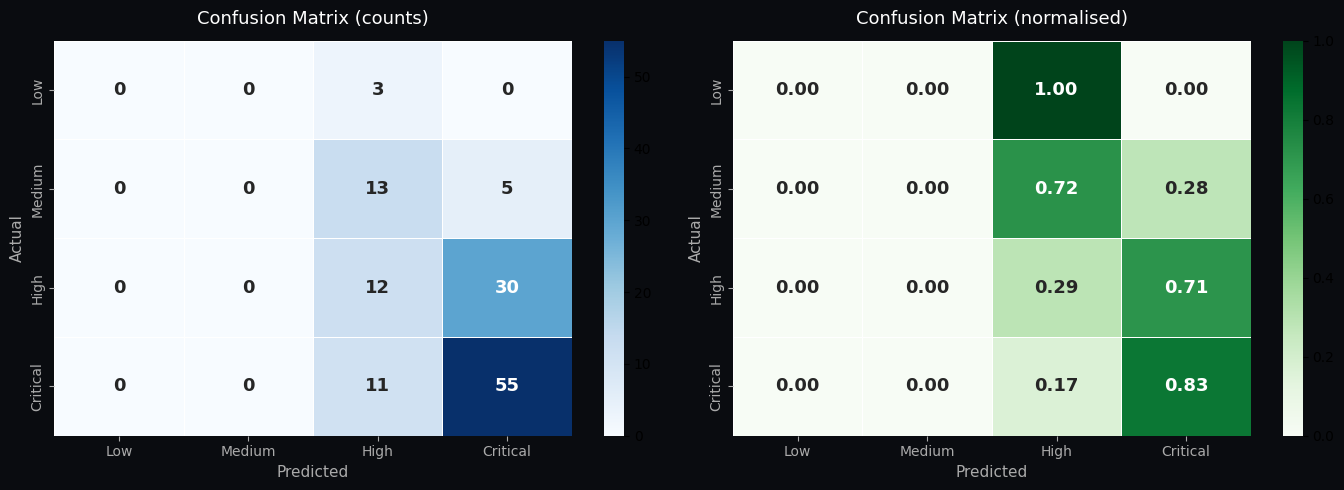


✅ Saved confusion_matrix.png

         YOLO DETECTION METRICS (from training)

  Model             : YOLOv8s
  Training images   : 5987 (BDD100K + VisDrone)
  Inference speed   : 7.6ms per frame
  Overall mAP50     : 0.503
  Overall mAP50-95  : 0.297

  Per-class mAP50:
    Car             : 0.800
    Bus             : 0.498
    Person          : 0.461
    Motorcycle      : 0.394
    Truck           : 0.363


In [24]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score,
                              recall_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns

# ── Reload best model ──
class CongestionLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(2, 128, 2, batch_first=True, dropout=0.3)
        self.fc   = nn.Sequential(nn.Linear(128,64), nn.ReLU(), nn.Dropout(0.2), nn.Linear(64,4))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class DensityDataset(Dataset):
    def __init__(self, data, window=20):
        self.window = window
        self.data   = data.copy().astype(np.float32)
        self.data[:, 0] /= 50.0
        self.data[:, 1] /= 3.0
    def __len__(self): return max(0, len(self.data) - self.window - 1)
    def __getitem__(self, idx):
        x = self.data[idx:idx+self.window]
        y = int(round(self.data[idx+self.window, 1] * 3))
        return torch.tensor(x), torch.tensor(max(0, min(3, y)), dtype=torch.long)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model  = CongestionLSTM().to(device)
model.load_state_dict(torch.load('/kaggle/working/lstm_congestion.pt', map_location=device))
model.eval()

df   = pd.read_csv('/kaggle/working/density_data.csv')
data = df[['count', 'level']].values
split = int(len(data) * 0.8)
val_ds     = DensityDataset(data[split:], window=20)
val_loader = DataLoader(val_ds, batch_size=32)

# ── Get predictions ──
all_preds, all_true = [], []
with torch.no_grad():
    for x, y in val_loader:
        out = model(x.to(device))
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_true.extend(y.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)
labels    = ['Low', 'Medium', 'High', 'Critical']

# ── Print all metrics ──
print("=" * 55)
print("         VISIONFLOW — LSTM EVALUATION METRICS")
print("=" * 55)

acc  = accuracy_score(all_true, all_preds)
prec = precision_score(all_true, all_preds, average='weighted', zero_division=0)
rec  = recall_score(all_true, all_preds, average='weighted', zero_division=0)
f1   = f1_score(all_true, all_preds, average='weighted', zero_division=0)

print(f"\n  Overall Accuracy  : {acc*100:.2f}%")
print(f"  Weighted Precision: {prec*100:.2f}%")
print(f"  Weighted Recall   : {rec*100:.2f}%")
print(f"  Weighted F1-Score : {f1*100:.2f}%")

print(f"\n  Macro Precision   : {precision_score(all_true, all_preds, average='macro', zero_division=0)*100:.2f}%")
print(f"  Macro Recall      : {recall_score(all_true, all_preds, average='macro', zero_division=0)*100:.2f}%")
print(f"  Macro F1-Score    : {f1_score(all_true, all_preds, average='macro', zero_division=0)*100:.2f}%")

print("\n" + "=" * 55)
print("  Per-Class Report")
print("=" * 55)
print(classification_report(all_true, all_preds,
      target_names=labels, zero_division=0))

# ── Confusion Matrix ──
cm = confusion_matrix(all_true, all_preds)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0a0c10')

# Raw confusion matrix
ax1 = axes[0]
ax1.set_facecolor('#0a0c10')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            ax=ax1, linewidths=0.5,
            annot_kws={'size': 13, 'weight': 'bold'})
ax1.set_title('Confusion Matrix (counts)', color='white', fontsize=13, pad=12)
ax1.set_xlabel('Predicted', color='#aaaaaa', fontsize=11)
ax1.set_ylabel('Actual',    color='#aaaaaa', fontsize=11)
ax1.tick_params(colors='#aaaaaa')

# Normalised confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
ax2 = axes[1]
ax2.set_facecolor('#0a0c10')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=labels, yticklabels=labels,
            ax=ax2, linewidths=0.5,
            annot_kws={'size': 13, 'weight': 'bold'})
ax2.set_title('Confusion Matrix (normalised)', color='white', fontsize=13, pad=12)
ax2.set_xlabel('Predicted', color='#aaaaaa', fontsize=11)
ax2.set_ylabel('Actual',    color='#aaaaaa', fontsize=11)
ax2.tick_params(colors='#aaaaaa')

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0c10')
plt.show()
print("\n✅ Saved confusion_matrix.png")

# ── YOLO metrics summary ──
print("\n" + "=" * 55)
print("         YOLO DETECTION METRICS (from training)")
print("=" * 55)
print(f"\n  Model             : YOLOv8s")
print(f"  Training images   : 5987 (BDD100K + VisDrone)")
print(f"  Inference speed   : 7.6ms per frame")
print(f"  Overall mAP50     : 0.503")
print(f"  Overall mAP50-95  : 0.297")
print(f"\n  Per-class mAP50:")
print(f"    Car             : 0.800")
print(f"    Bus             : 0.498")
print(f"    Person          : 0.461")
print(f"    Motorcycle      : 0.394")
print(f"    Truck           : 0.363")
print("=" * 55)